In [1]:
# Get filenames

import json

with open("./data/real_world/all.json", "r") as f:
    all = json.load(f)

month_files = []
for key, value in all.items():
    file_name = f"./data/real_world/months_raw/{key}.raw"
    month_files.append(file_name)

In [19]:
# Set cutoff
CUTOFF = 0.5

In [3]:
# Get years 2010-2014 for our ground truth
test_years = [str(i) for i in range(2010, 2015)]
test_files = []
eval_files = []

for file in month_files:
    if file.split("/")[-1][:4] in test_years:
        test_files.append(file)
    else:
        eval_files.append(file)

In [4]:
len(test_files)

60

In [5]:
len(eval_files)

132

In [6]:
import numpy as np

def evaluate_paper(gbm_data, cutoff):
    # GBM data is a vector of [human, AI] probabilities
    
    # Convert vector into np array
    probs = np.array(gbm_data)
    
    # Get AI probabilities after transforming matrix
    ai_probs = probs.T[1]
    
    # Get all sentences over cutoff
    ai_sentences = ai_probs >= cutoff
    
    # Get three consecutive sentences
    sliding_window = ai_sentences[:-2] & ai_sentences[1:-1] & ai_sentences[2:]
    
    # Count identified paragraphs
    ai_paragraphs = (sliding_window == True).sum()
    
    # Return boolean value indicating whether we found something
    return ai_paragraphs > 0

In [13]:
# Evaluate test files
import pickle
import torch
from tqdm import tqdm

collected_test_data = []

for i in tqdm(range(len(test_files))):
    file = test_files[i]
    
    # Load file
    with open(file, "rb") as f:
        data = pickle.load(f)
        
        if not "papers" in data:
            print(f"{file} does not contain any data!!!")
            continue
        
        # Get gbm data
        papers = data["papers"]
        nr_papers = 0
        for paper in list(papers.keys()):
            test_paper = papers[paper]
            
            # Only use paper where gbm data is present
            if not "gbm" in test_paper:
                print(f"No gbm data present for {paper}")
                continue
            
            # Only consider papers that have sentences
            if len(test_paper["sentences"]) == 0:
                continue
            
            # Only consider English papers
            if test_paper["lang"] != "en":
                continue
            
            # Only consider 250 papers
            nr_papers += 1
            if nr_papers > 250:
                break
            
            gbm_data = test_paper["gbm"]
            collected_test_data.append(gbm_data.T[1])
            
        if nr_papers < 250:
            print(f"less than 250 papers in {file}")
            
    torch.cuda.empty_cache()

 58%|█████▊    | 35/60 [00:00<00:00, 52.27it/s]

No gbm data present for 1102.4873v1
No gbm data present for 1012.4688v1


100%|██████████| 60/60 [00:01<00:00, 49.00it/s]


In [20]:
import numpy as np

sentence_scores = []
# Iterate over collected GBM data -> compute percentage of sentences over cutoff

for gbm_data in collected_test_data:
    gbm_data = np.array(gbm_data)
    score = (gbm_data >= CUTOFF).sum() / len(gbm_data)
    sentence_scores.append(score)

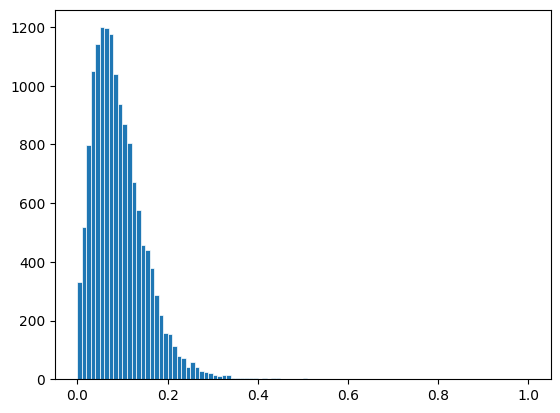

In [21]:
# Show histogram of sentence scores (central limit theorem)
import matplotlib.pyplot as plt

fix, ax = plt.subplots()
ax.hist(sentence_scores, bins=100, linewidth=0.5, edgecolor="white")
plt.show()

In [10]:
# Compute mean
overall_mean = np.array(sentence_scores).mean()
overall_mean

np.float64(0.01548555864684738)

In [11]:
# Compute standard deviation with one degree of freedom -> correction of std dev
std = np.std(sentence_scores, ddof=1)
std

np.float64(0.019193011781399594)

In [13]:
# standard error of the mean
std_err = (((std ** 2) / len(sentence_scores)) ** 0.5) # std was already corrected above
std_err

np.float64(0.0004906118667750598)

In [14]:
sentence_scores = np.array(sentence_scores)
(sentence_scores > (overall_mean + 3.09*std)).sum() / len(sentence_scores)

np.float64(0.011)

In [15]:
import pickle
from tqdm import tqdm
import scipy

test_probas = [0.75, 0.9, 0.95, 0.975]
occurrences = []

# Evaluate files
for i in tqdm(range(len(eval_files))):
    file = eval_files[i]
    
    # Load file
    with open(file, "rb") as f:
        month_data = pickle.load(f)
        
    # Check if there are papers
    if not "papers" in month_data:
        print(f"{file} does not contain any data!!!")
        continue
                
    nr_papers = 0
    # Arry to store occurrences
    month_occurrences = [0] * len(test_probas)
    confidence_o = []
    
    # Get individual papers
    for arxiv_identifier, paper_data in month_data["papers"].items():
        if not "gbm" in paper_data:
            print(f"No GBM data found in {file} / {arxiv_identifier}")
            continue
        
        # Only consider papers that have sentences
        if len(paper_data["sentences"]) == 0:
            continue
        
        # Only consider English papers
        if test_paper["lang"] != "en":
            continue
        
        # Only consider 250 papers
        nr_papers += 1
        if nr_papers > 250:
            break
        
        # Found file: evaluate
        for i in range(len(test_probas)):
            prob = test_probas[i]
            found = evaluate_paper(month_data["papers"][arxiv_identifier]["gbm"], prob)
            
            # Increase found occurrences by one
            if found:
                month_occurrences[i] += 1
                
        # Compute confidence
        gbm_probas = month_data["papers"][arxiv_identifier]["gbm"]
        result = ((gbm_probas.T[1] > CUTOFF) == True).sum() / len(gbm_probas.T[1])
        confidence_o.append(result)
        
    if nr_papers < 250:
        print(f"Less than 250 papers in {file}")
        
    confidence_o = np.array(confidence_o)
    median = np.median(confidence_o)
    confidence_lower = median - 3.291 * std_err
    confidence_upper = median + 3.291 * std_err
    occurrences_z = (np.array(confidence_o) - overall_mean) / std
    p_value = 0.001
    not_passed = 0
    
    for score in occurrences_z:
        p_value_right = scipy.stats.norm.sf(score)
        passed = p_value_right >= p_value
        if not passed:
            not_passed += 1
    
                
    # Store
    month_data["probas"] = test_probas
    month_data["occurrences"] = month_occurrences   
    occurrences.append({
        "ym": month_data["ym"],
        "occurrences": month_data["occurrences"],
        "occurrences_z": not_passed,
        "confidence_lower": confidence_lower,
        "confidence_upper": confidence_upper
    }) 
    
    # Store
    with open(file, "wb") as f:
        pickle.dump(month_data, f)

100%|██████████| 132/132 [00:07<00:00, 17.26it/s]


In [16]:
occurrences

[{'ym': '20170401',
  'occurrences': [60, 29, 20, 8],
  'occurrences_z': 6,
  'confidence_lower': np.float64(0.10544519701089511),
  'confidence_upper': np.float64(0.10867440431800854)},
 {'ym': '20170101',
  'occurrences': [60, 33, 14, 5],
  'occurrences_z': 6,
  'confidence_lower': np.float64(0.09786039703361517),
  'confidence_upper': np.float64(0.1010896043407286)},
 {'ym': '20220901',
  'occurrences': [107, 67, 48, 25],
  'occurrences_z': 16,
  'confidence_lower': np.float64(0.15874253920358614),
  'confidence_upper': np.float64(0.1619717465106996)},
 {'ym': '20220301',
  'occurrences': [112, 61, 39, 24],
  'occurrences_z': 15,
  'confidence_lower': np.float64(0.15056530623386824),
  'confidence_upper': np.float64(0.1537945135409817)},
 {'ym': '20150601',
  'occurrences': [51, 29, 17, 9],
  'occurrences_z': 2,
  'confidence_lower': np.float64(0.0982838699495801),
  'confidence_upper': np.float64(0.10151307725669353)},
 {'ym': '20181101',
  'occurrences': [86, 42, 31, 7],
  'occurr

In [17]:
import pickle

with open("./data/real_world/final", "wb") as f:
    pickle.dump(occurrences, f)

In [18]:
# Get sorted occurrences
occurrences_sorted = sorted(occurrences, key=lambda item: item["ym"])

In [19]:
# Get months and occurrences
months = []
occurrences_ordered = []
for item in occurrences_sorted:
    months.append(f'{item["ym"][:4]}-{item["ym"][4:6]}' if item["ym"][4:6] == "01" or item["ym"][4:6] == "07" else "")
    occurrences_ordered.append(item["occurrences"])

In [20]:
# Get occurrences by month
import numpy as np
occurrences_month = np.array(occurrences_ordered)
occurrences_month = occurrences_month.T

In [21]:
occurrences_month_percentage = occurrences_month / 250.0 * 100

In [22]:
print(occurrences_sorted)

[{'ym': '20150101', 'occurrences': [45, 19, 12, 3], 'occurrences_z': 1, 'confidence_lower': np.float64(0.08171490266102423), 'confidence_upper': np.float64(0.08494410996813766)}, {'ym': '20150201', 'occurrences': [65, 31, 21, 10], 'occurrences_z': 5, 'confidence_lower': np.float64(0.09594685160701359), 'confidence_upper': np.float64(0.09917605891412702)}, {'ym': '20150301', 'occurrences': [53, 28, 17, 9], 'occurrences_z': 2, 'confidence_lower': np.float64(0.09270166083532641), 'confidence_upper': np.float64(0.09593086814243984)}, {'ym': '20150401', 'occurrences': [64, 27, 16, 8], 'occurrences_z': 4, 'confidence_lower': np.float64(0.09482866335506739), 'confidence_upper': np.float64(0.09805787066218082)}, {'ym': '20150501', 'occurrences': [50, 25, 13, 7], 'occurrences_z': 1, 'confidence_lower': np.float64(0.09229872387257569), 'confidence_upper': np.float64(0.09552793117968912)}, {'ym': '20150601', 'occurrences': [51, 29, 17, 9], 'occurrences_z': 2, 'confidence_lower': np.float64(0.0982

In [23]:
def get_month_index(ym):
    for i in range(len(occurrences_sorted)):
        o = occurrences_sorted[i]
        if o["ym"] == ym:
            return i
        
    return 0

In [24]:
ax2_labels = [""] * len(occurrences)
ax2_labels[get_month_index("20171201")] = "Transformers"
ax2_labels[get_month_index("20180601")] = "GPT"
ax2_labels[get_month_index("20190201")] = "GPT-2 small"
ax2_labels[get_month_index("20190501")] = "GPT-2 medium"
ax2_labels[get_month_index("20190801")] = "GPT-2 large"
ax2_labels[get_month_index("20191101")] = "GPT-2"
ax2_labels[get_month_index("20200501")] = "GPT-3"
ax2_labels[get_month_index("20220301")] = "GPT-3.5"
ax2_labels[get_month_index("20221101")] = "ChatGPT"
ax2_labels[get_month_index("20230301")] = "GPT-4"
ax2_labels[get_month_index("20240501")] = "GPT-4o"
ax2_labels[get_month_index("20250201")] = "GPT-4.5"
ax2_labels[get_month_index("20250401")] = "GPT-4.1"
ax2_labels[get_month_index("20250801")] = "GPT-5"
ax2_labels[get_month_index("20251101")] = "GPT-5.1"
ax2_labels[get_month_index("20251201")] = "GPT-5.2"

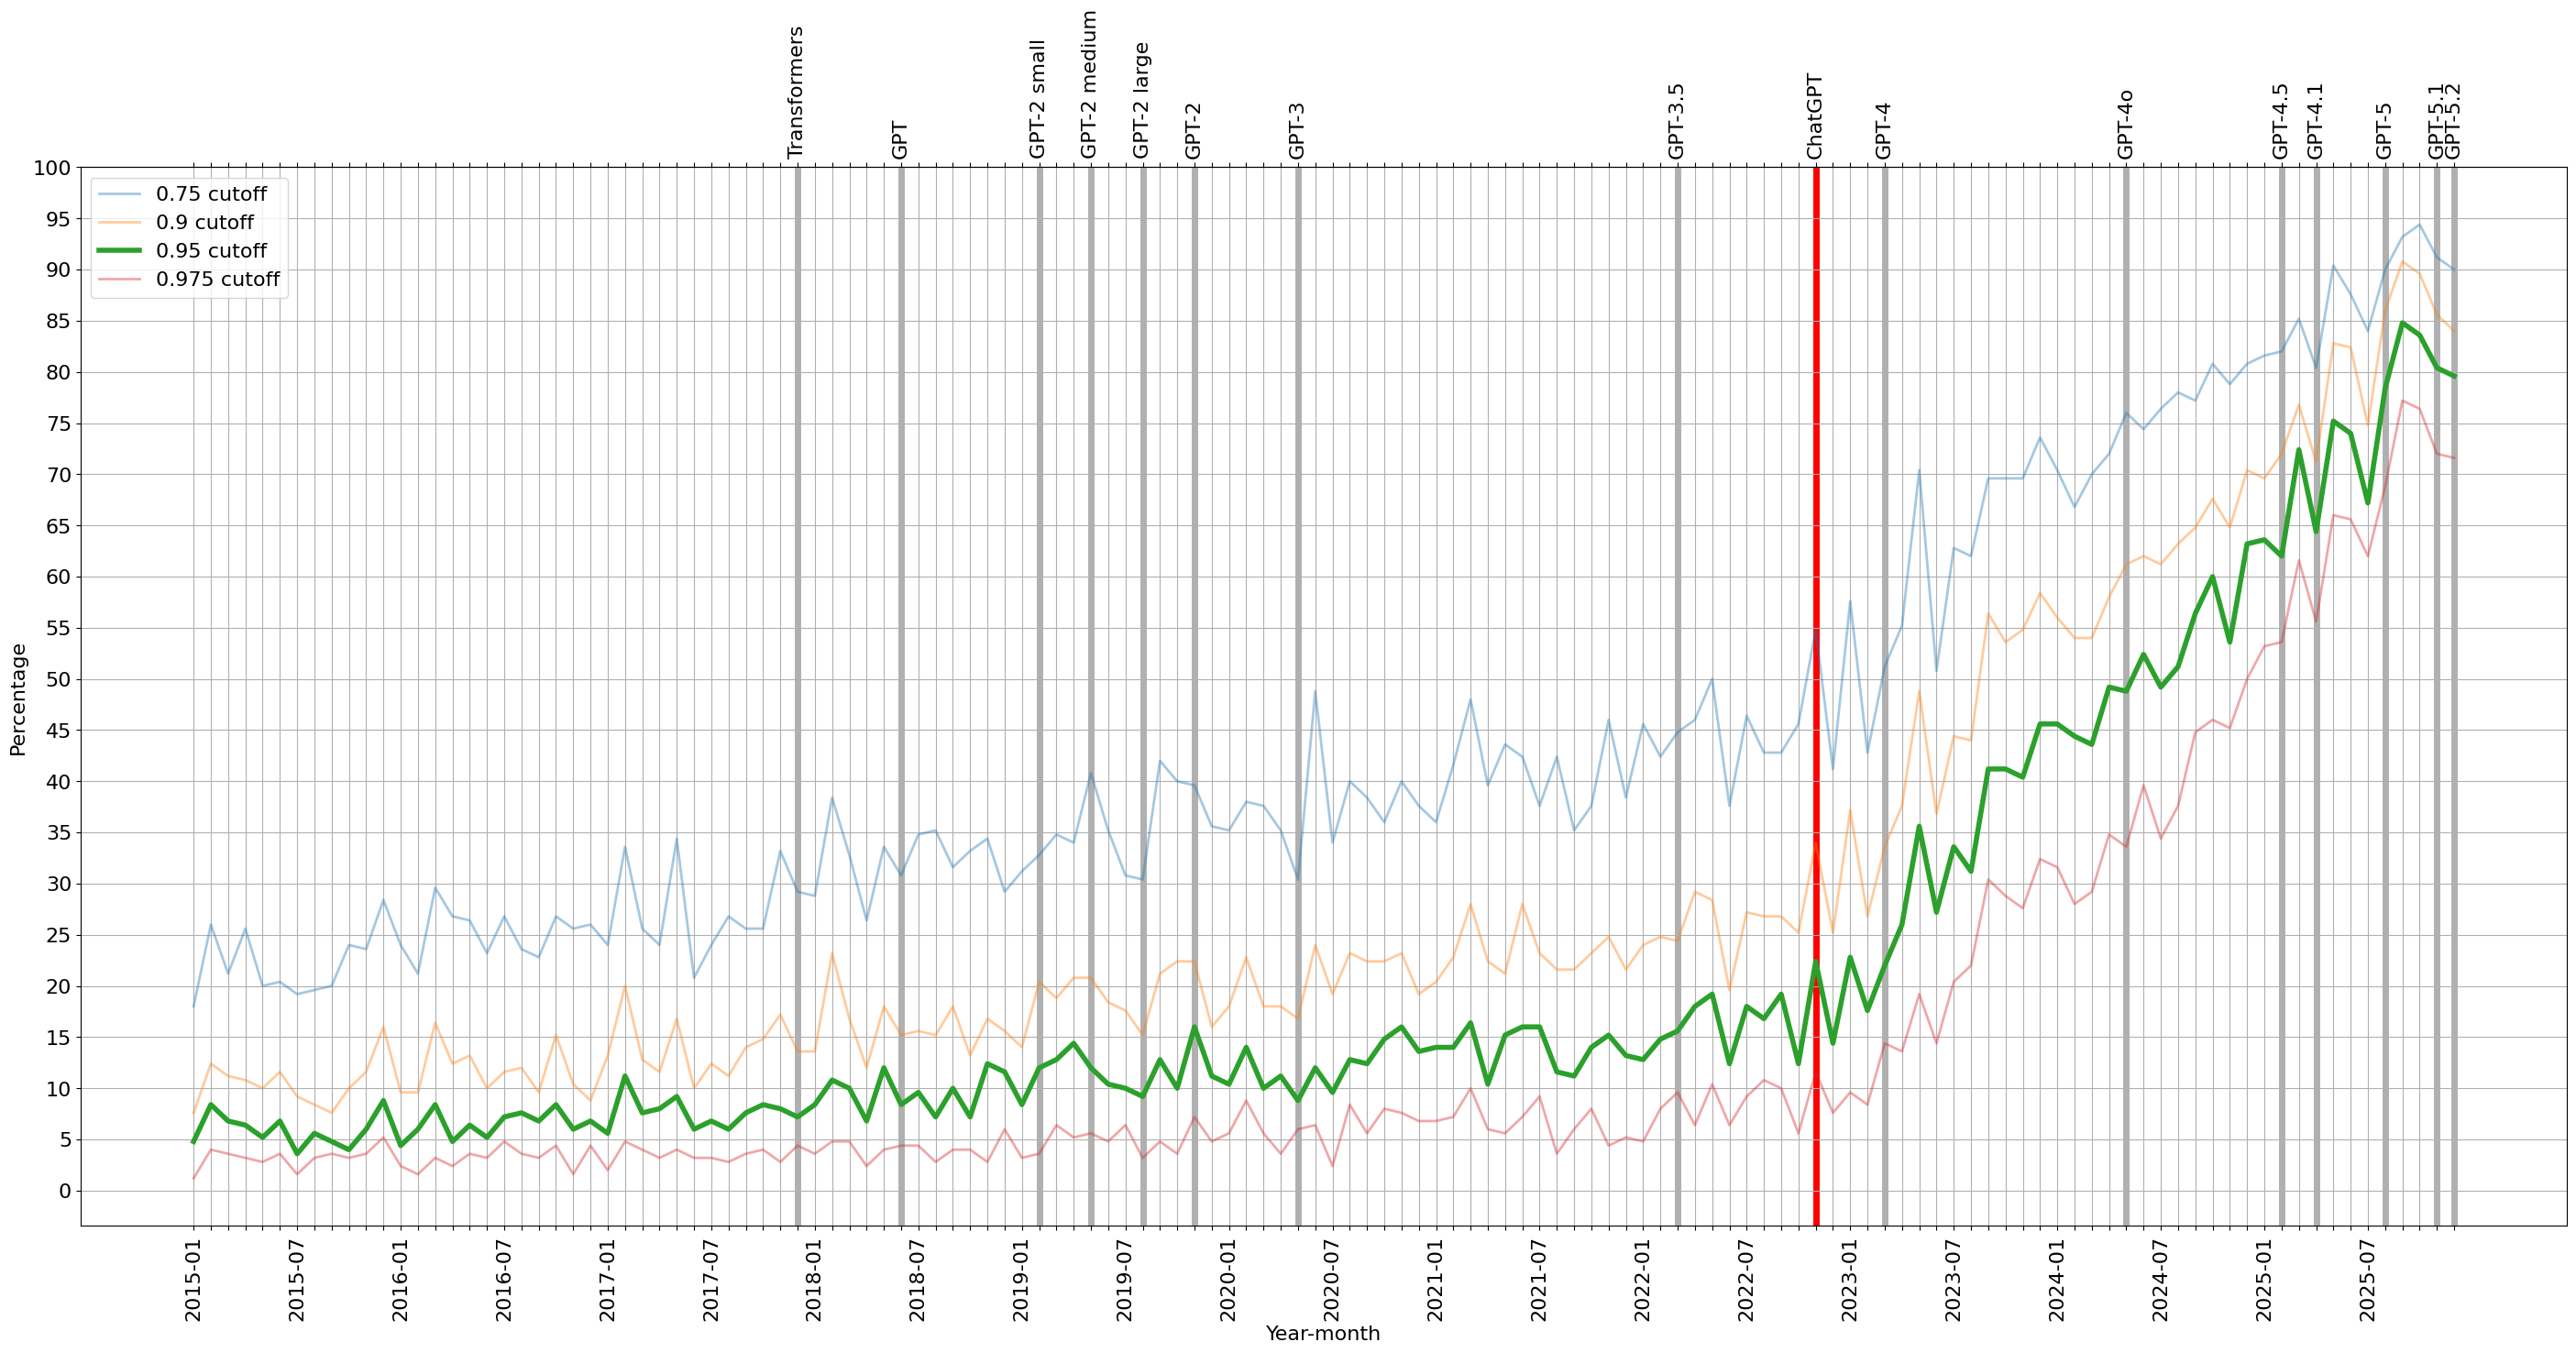

In [25]:
# Plot occurrences
import matplotlib.pyplot as plt

# Increase font size
plt.rcParams.update({"font.size": 16})

# X values for the months
x = np.arange(0, len(months))
x_s = np.linspace(x.min(), x.max(), 1000)

# Create figures
fig, ax = plt.subplots()
fig.set_size_inches(35, 15)

MIN = 0
MAX = len(test_probas)

# Plot for each proba
for i in range(MIN, MAX):
    prob = test_probas[i]
    occurrences = occurrences_month_percentage[i]
    ax.plot(x, occurrences, '-', label=f"{prob} cutoff", alpha=1 if i == 2 else 0.4, linewidth=4 if i == 2 else 2)

ax.set_xticks(x)
ax.set_xticklabels(months, rotation=90)
plt.yticks(np.arange(0, 101, 5))
ax2 = ax.secondary_xaxis("top")
ax2.set_xticks(x)
ax2.set_xticklabels(ax2_labels, rotation=90)
plt.xlabel("Year-month")
plt.ylabel("Percentage")
ax.grid()

# customize grid
for gridline, tick in zip(ax.get_xgridlines(), ax.get_xticks()):
    if len(ax2_labels[tick]) > 0:
        gridline.set_linewidth(5)
    if "chatgpt" in ax2_labels[tick].lower():
        gridline.set_color('r')

plt.legend()
plt.savefig("./data/figures/anomalies.pdf")
plt.show()

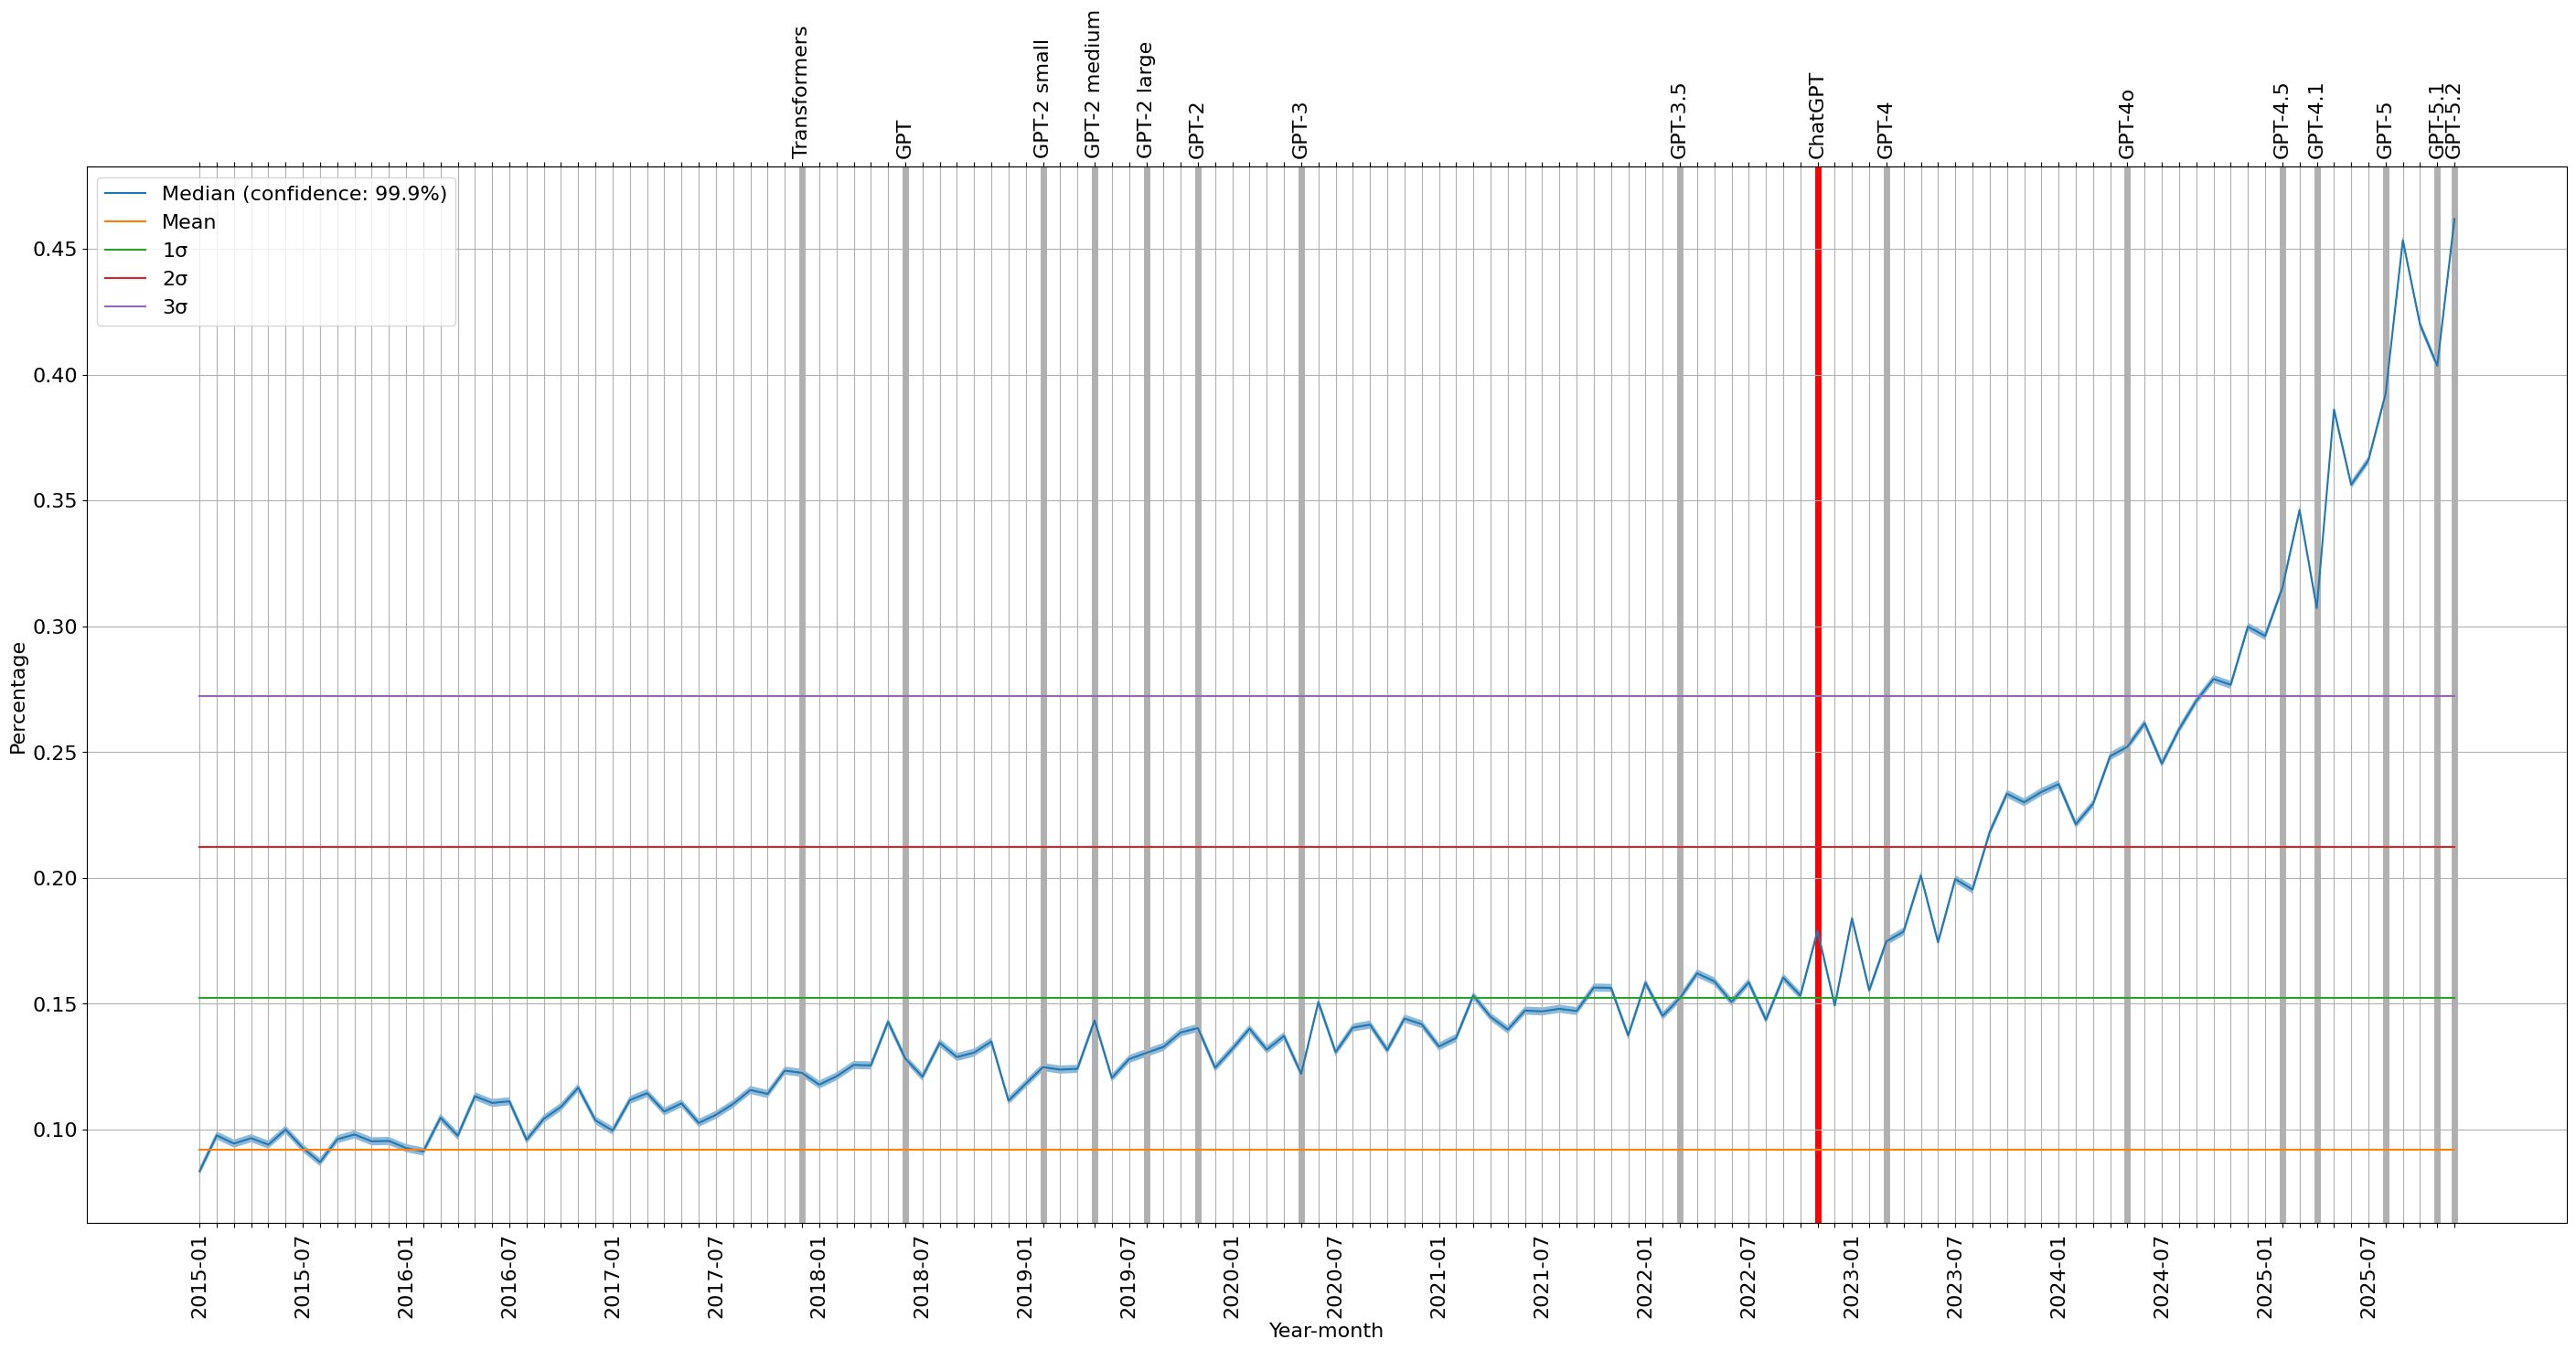

In [26]:
# Plot occurrences (medians)
import matplotlib.pyplot as plt

# Increase font size
plt.rcParams.update({"font.size": 16})

# X values for the months
x = np.arange(0, len(months))
x_s = np.linspace(x.min(), x.max(), 1000)

# Create figures
fig, ax = plt.subplots()
fig.set_size_inches(35, 15)

confidence_lower = [month["confidence_lower"] for month in occurrences_sorted]
confidence_upper = [month["confidence_upper"] for month in occurrences_sorted]
confidence_mean = (np.array(confidence_lower) + np.array(confidence_upper)) / 2
mean = [overall_mean] * len(months)
s1 = [overall_mean + std] * len(months)
s2 = [overall_mean + 2*std] * len(months)
s3 = [overall_mean + 3*std] * len(months)
ax.fill_between(x, confidence_lower, confidence_upper, alpha=.5, linewidth=0)
ax.plot(x, confidence_mean, '-', label=f"Median (confidence: 99.9%)")
ax.plot(x, mean, '-', label=f"Mean")
ax.plot(x, s1, '-', label=f"1σ")
ax.plot(x, s2, '-', label=f"2σ")
ax.plot(x, s3, '-', label=f"3σ")

ax.set_xticks(x)
ax.set_xticklabels(months, rotation=90)
#plt.yticks(np.arange(0, 101, 5))
ax2 = ax.secondary_xaxis("top")
ax2.set_xticks(x)
ax2.set_xticklabels(ax2_labels, rotation=90)
plt.xlabel("Year-month")
plt.ylabel("Percentage")
ax.grid()

# customize grid
for gridline, tick in zip(ax.get_xgridlines(), ax.get_xticks()):
    if len(ax2_labels[tick]) > 0:
        gridline.set_linewidth(5)
    if "chatgpt" in ax2_labels[tick].lower():
        gridline.set_color('r')

plt.legend()
plt.savefig("./data/figures/anomalies_median.pdf")
plt.show()

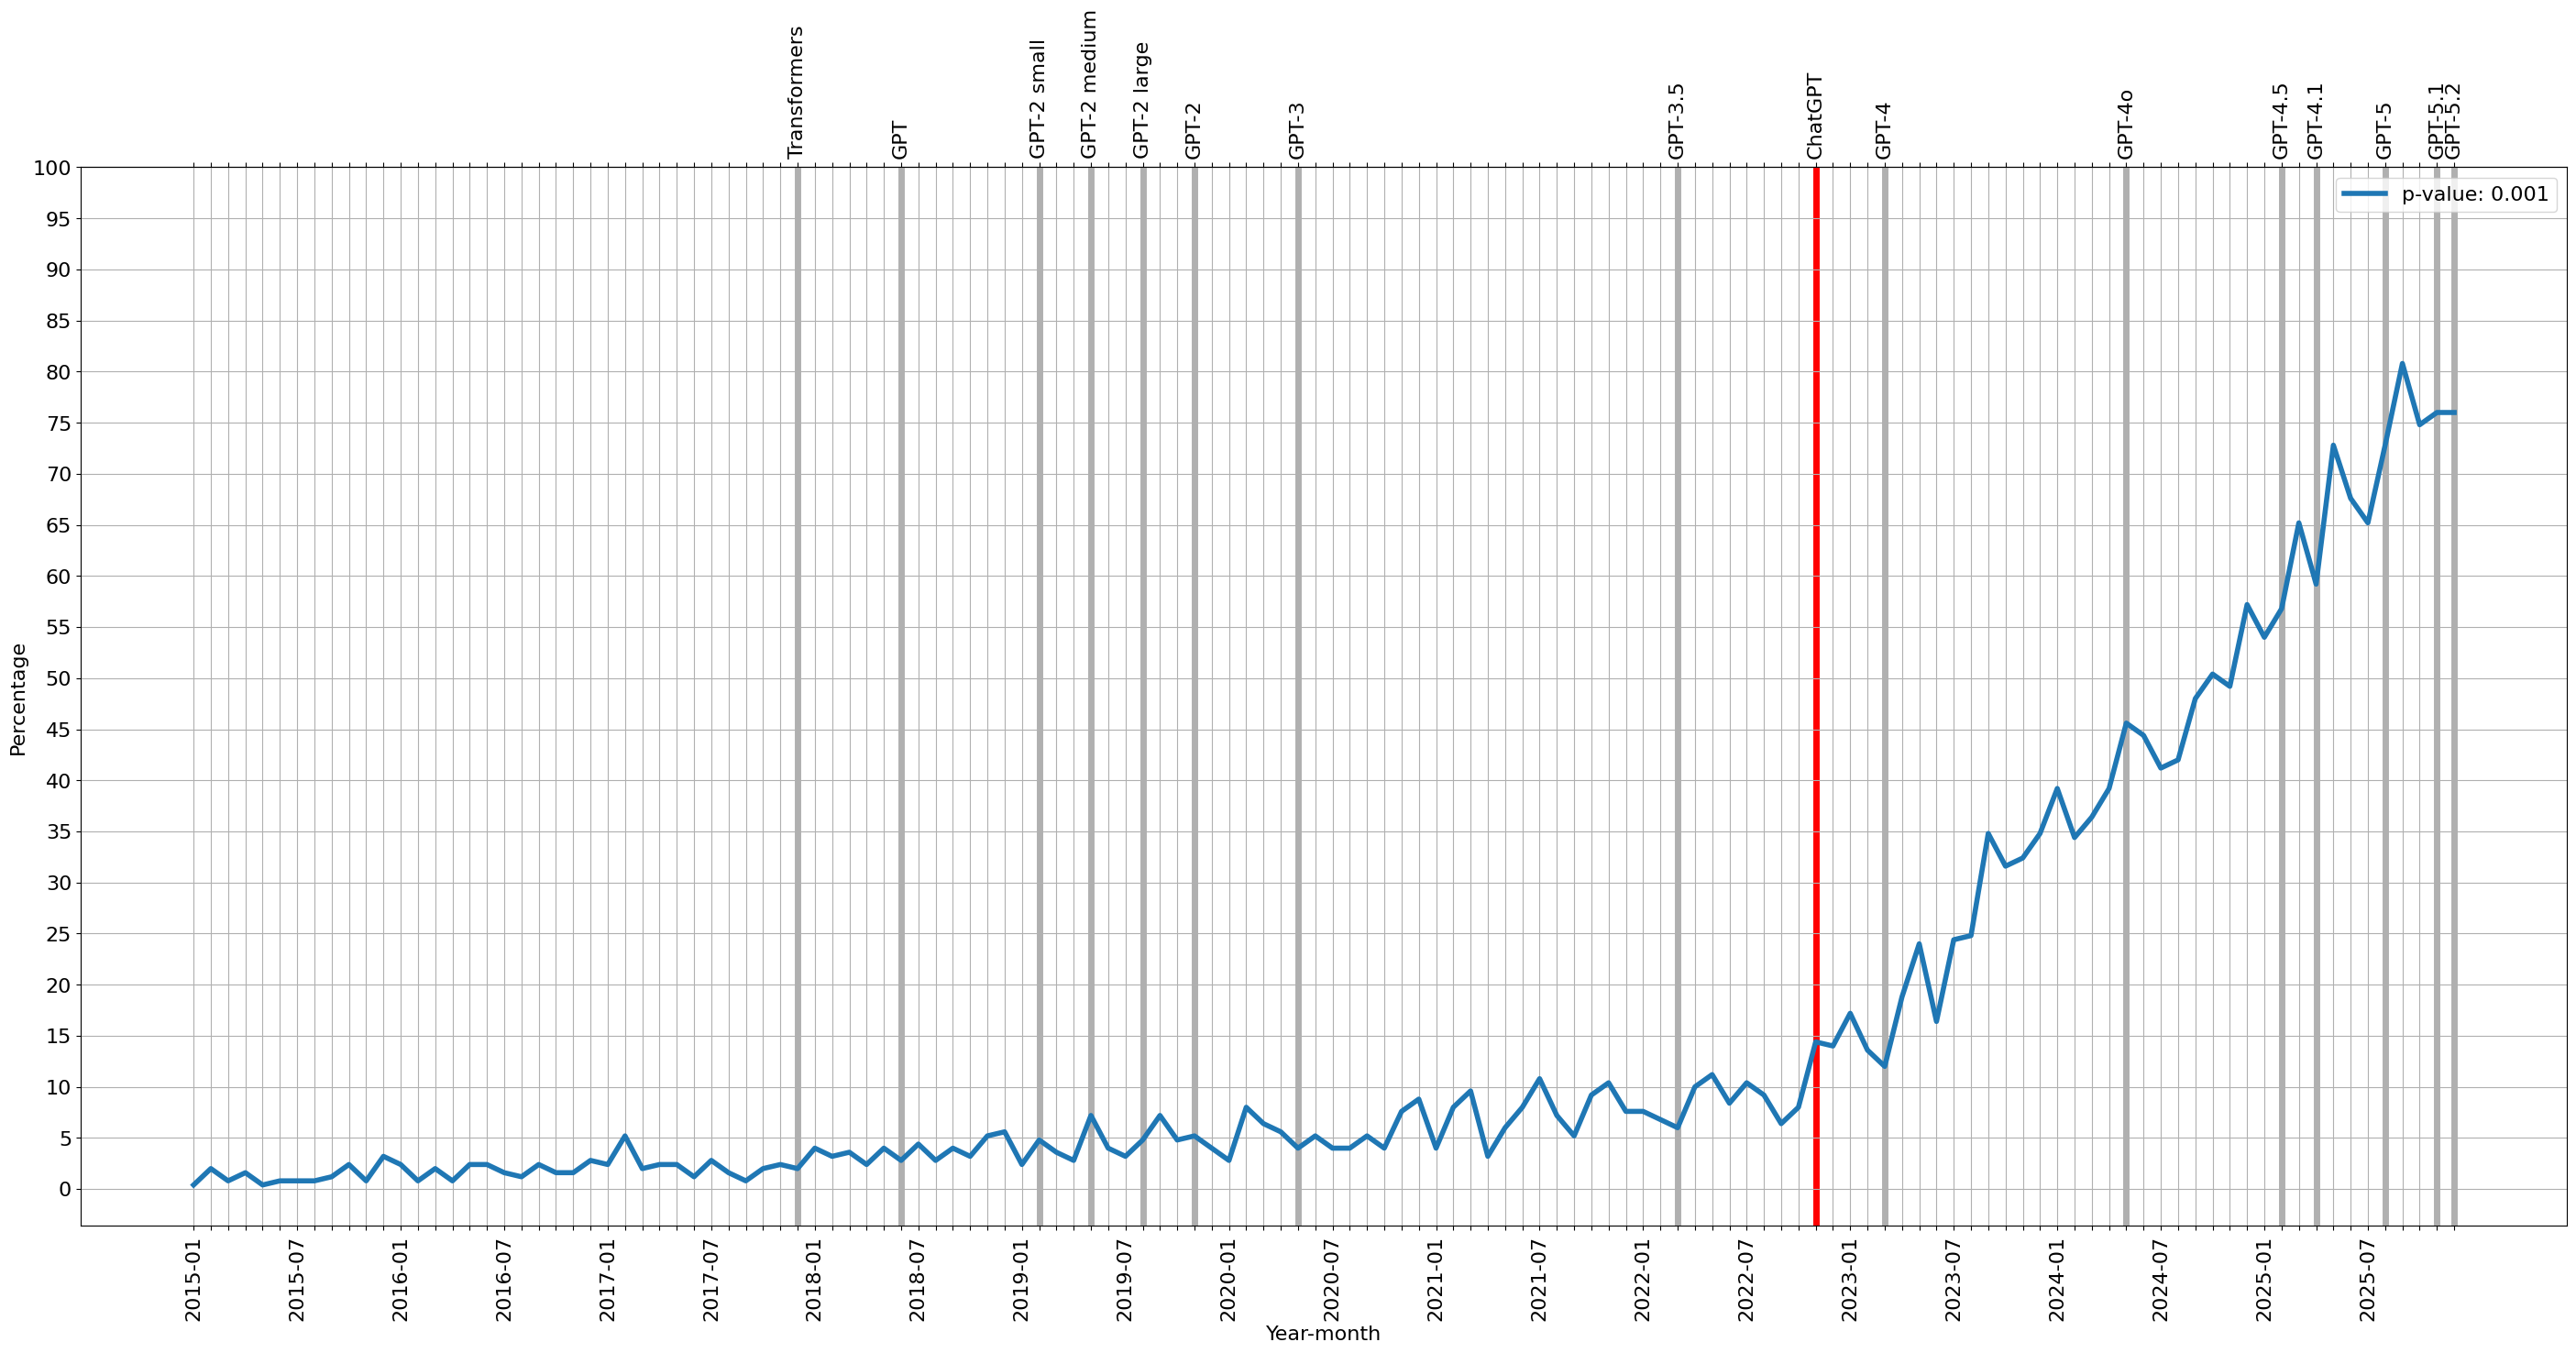

In [27]:
# Plot occurrences (medians)
import matplotlib.pyplot as plt

# Increase font size
plt.rcParams.update({"font.size": 16})

# X values for the months
x = np.arange(0, len(months))
x_s = np.linspace(x.min(), x.max(), 1000)

# Create figures
fig, ax = plt.subplots()
fig.set_size_inches(35, 15)

occurrences = np.array([month["occurrences_z"] for month in occurrences_sorted]) / 250.0 * 100
ax.plot(x, occurrences, '-', label=f"p-value: 0.001", linewidth=4)

ax.set_xticks(x)
ax.set_xticklabels(months, rotation=90)
plt.yticks(np.arange(0, 101, 5))
ax2 = ax.secondary_xaxis("top")
ax2.set_xticks(x)
ax2.set_xticklabels(ax2_labels, rotation=90)
plt.xlabel("Year-month")
plt.ylabel("Percentage")
ax.grid()

# customize grid
for gridline, tick in zip(ax.get_xgridlines(), ax.get_xticks()):
    if len(ax2_labels[tick]) > 0:
        gridline.set_linewidth(5)
    if "chatgpt" in ax2_labels[tick].lower():
        gridline.set_color('r')

plt.legend()
plt.savefig("./data/figures/anomalies_p.pdf")
plt.show()

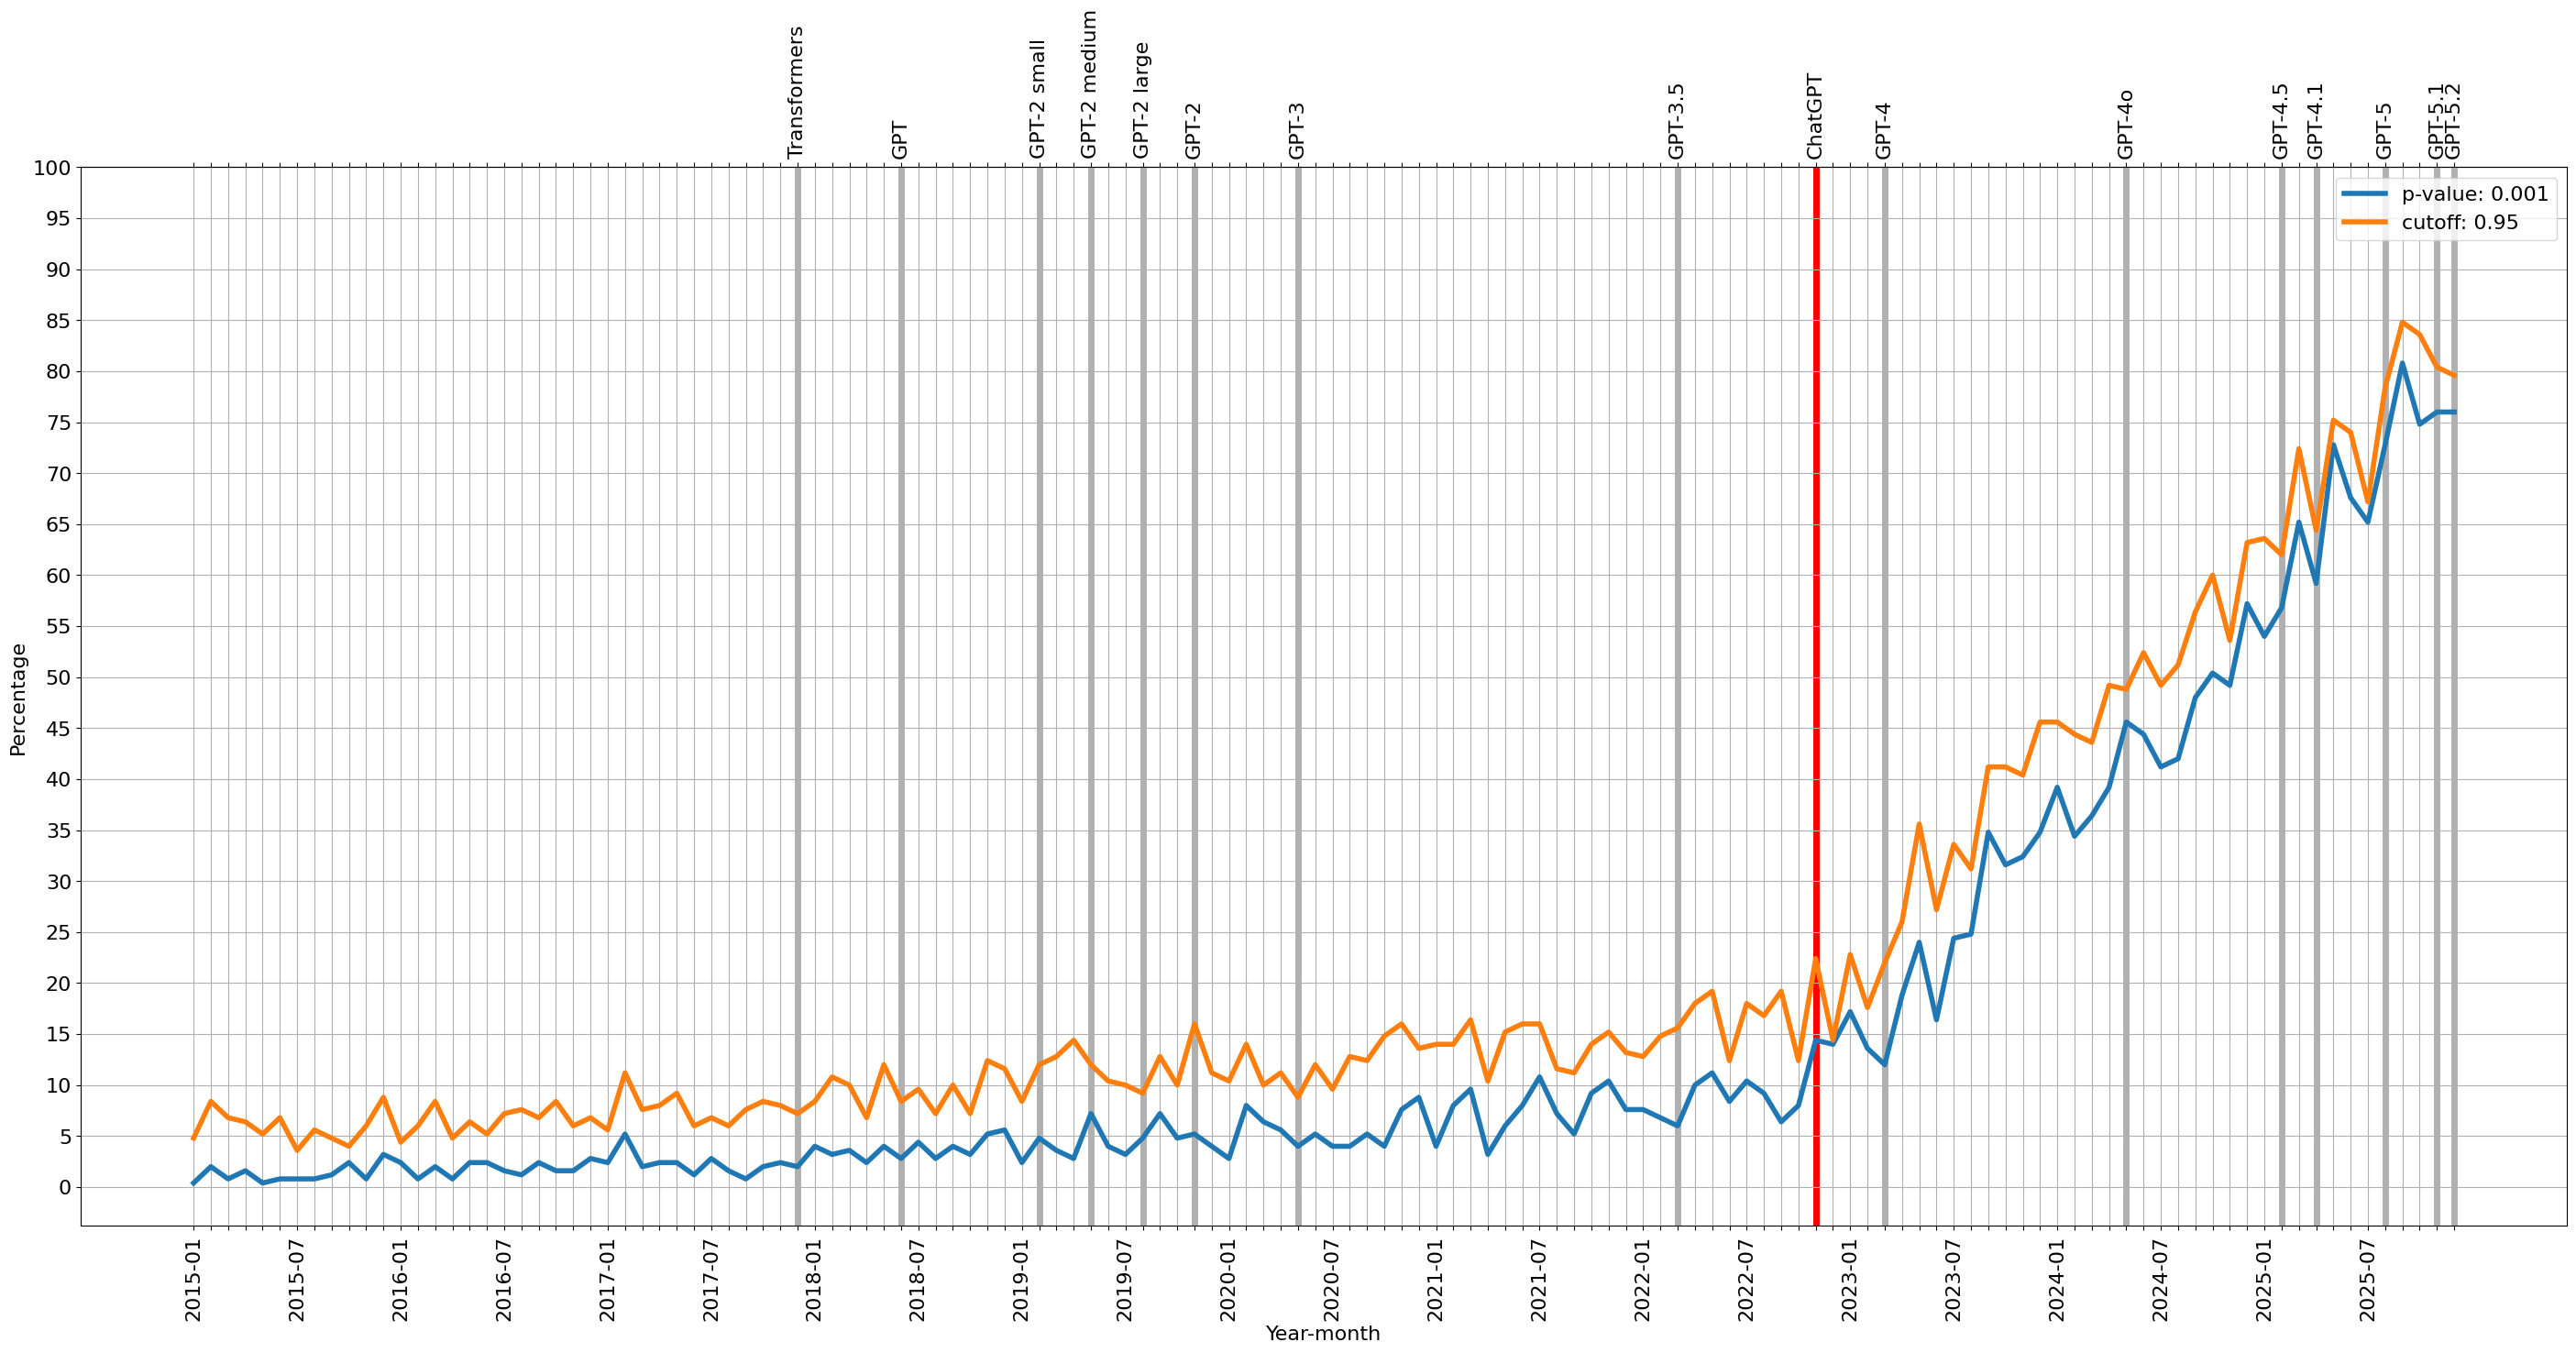

In [28]:
# Plot occurrences (medians)
import matplotlib.pyplot as plt

# Increase font size
plt.rcParams.update({"font.size": 16})

# X values for the months
x = np.arange(0, len(months))
x_s = np.linspace(x.min(), x.max(), 1000)

# Create figures
fig, ax = plt.subplots()
fig.set_size_inches(35, 15)

occurrences = np.array([month["occurrences_z"] for month in occurrences_sorted]) / 250.0 * 100
ax.plot(x, occurrences, '-', label=f"p-value: 0.001", linewidth=4)

occurrences = occurrences_month_percentage[2]
ax.plot(x, occurrences, '-', label=f"cutoff: 0.95", linewidth=4)

ax.set_xticks(x)
ax.set_xticklabels(months, rotation=90)
plt.yticks(np.arange(0, 101, 5))
ax2 = ax.secondary_xaxis("top")
ax2.set_xticks(x)
ax2.set_xticklabels(ax2_labels, rotation=90)
plt.xlabel("Year-month")
plt.ylabel("Percentage")
ax.grid()

# customize grid
for gridline, tick in zip(ax.get_xgridlines(), ax.get_xticks()):
    if len(ax2_labels[tick]) > 0:
        gridline.set_linewidth(5)
    if "chatgpt" in ax2_labels[tick].lower():
        gridline.set_color('r')

plt.legend()
plt.savefig("./data/figures/anomalies_p.pdf")
plt.show()